In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/Clean Data')
print(os.listdir())


Mounted at /content/drive
['df_census.csv', 'df_people.csv', 'df_crashes.csv', 'df_vehicles.csv', 'df_redlights.csv', 'df_speeding.csv', 'df_cameras.csv', 'catboost_info', 'injury_severity_model.pkl']


In [ ]:
import pandas as pd
df_crashes=pd.read_csv("df_crashes.csv")

In [ ]:
import pandas as pd

df = df_crashes.copy()

# --- 1) Make the binary target ---
df["SEVERE_BIN"] = ((df["INJURIES_FATAL"] > 0) | (df["INJURIES_INCAPACITATING"] > 0)).astype(int)

# Quick sanity check on class balance
pos = df["SEVERE_BIN"].sum()
neg = (1 - df["SEVERE_BIN"]).sum()
print(f"Severe=1: {pos:,}  |  Non-severe=0: {neg:,}  |  Pos-rate: {pos/len(df):.4%}")

# --- 2) Drop outcome leakage + identifiers ---
leakage_cols = [
    # direct outcomes / near-outcomes
    "INJURIES_TOTAL","INJURIES_FATAL","INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING","INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION","MOST_SEVERE_INJURY","DAMAGE",
    # timestamps/IDs/free-text not meant for modeling
    "CRASH_RECORD_ID","CRASH_DATE","DATE_POLICE_NOTIFIED",
    "STREET_NO","STREET_NAME"
]

# keep causes for now (they are predictive and available in reports);


X = df.drop(columns=leakage_cols + ["SEVERE_BIN"])
y = df["SEVERE_BIN"]

print("X shape:", X.shape, "| y shape:", y.shape)
X.head().T.head(20)

Severe=1: 15,791  |  Non-severe=0: 933,319  |  Pos-rate: 1.6638%
X shape: (949110, 25) | y shape: (949110,)


,0,1,2,3,4
POSTED_SPEED_LIMIT,30,30,25,25,35
TRAFFIC_CONTROL_DEVICE,TRAFFIC SIGNAL,NO CONTROLS,STOP SIGN/FLASHER,NO CONTROLS,NO CONTROLS
DEVICE_CONDITION,FUNCTIONING PROPERLY,NO CONTROLS,UNKNOWN,NO CONTROLS,NO CONTROLS
WEATHER_CONDITION,RAIN,OTHER,RAIN,CLEAR,CLEAR
LIGHTING_CONDITION,"DARKNESS, LIGHTED ROAD","DARKNESS, LIGHTED ROAD","DARKNESS, LIGHTED ROAD","DARKNESS, LIGHTED ROAD",DARKNESS
FIRST_CRASH_TYPE,REAR TO FRONT,PARKED MOTOR VEHICLE,FIXED OBJECT,PARKED MOTOR VEHICLE,SIDESWIPE SAME DIRECTION
TRAFFICWAY_TYPE,FOUR WAY,NOT DIVIDED,T-INTERSECTION,ONE-WAY,NOT DIVIDED
ALIGNMENT,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL
ROADWAY_SURFACE_COND,WET,OTHER,WET,WET,WET
ROAD_DEFECT,NO DEFECTS,NO DEFECTS,UNKNOWN,NO DEFECTS,NO DEFECTS


In [ ]:
# ---Remove BEAT_OF_OCCURRENCE ---
if "BEAT_OF_OCCURRENCE" in X.columns:
    X = X.drop(columns=["BEAT_OF_OCCURRENCE"])

# ---Convert time & region columns to categorical ---
cat_time_cols = ["CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "zipcode"]

# Fill missing zipcodes with a placeholder (string) before converting
X["zipcode"] = X["zipcode"].fillna("unknown").astype(str)

for col in cat_time_cols:
    X[col] = X[col].astype("category")

# ---Double-check categorical summary ---
cat_summary = {col: X[col].nunique() for col in cat_time_cols}
print("Categorical columns:", cat_summary)
print("\nFinal feature count:", X.shape[1])


Categorical columns: {'CRASH_HOUR': 24, 'CRASH_DAY_OF_WEEK': 7, 'CRASH_MONTH': 12, 'zipcode': 60}

Final feature count: 24


In [ ]:
# copy
df_model = X.copy()

# -Numeric, binary, and categorical base features ---
numeric_cols = [
    'POSTED_SPEED_LIMIT','NUM_UNITS','LATITUDE','LONGITUDE'
]
binary_cols = ['INTERSECTION_RELATED_I','HIT_AND_RUN_I']
cat_cols = [
    'TRAFFIC_CONTROL_DEVICE','DEVICE_CONDITION','WEATHER_CONDITION','LIGHTING_CONDITION',
    'FIRST_CRASH_TYPE','TRAFFICWAY_TYPE','ALIGNMENT','ROADWAY_SURFACE_COND',
    'ROAD_DEFECT','REPORT_TYPE','CRASH_TYPE','PRIM_CONTRIBUTORY_CAUSE',
    'SEC_CONTRIBUTORY_CAUSE','STREET_DIRECTION','CRASH_HOUR','CRASH_DAY_OF_WEEK',
    'CRASH_MONTH','zipcode'
]

# -Feature engineering ---
# Weekend indicator
df_model['IS_WEEKEND'] = df_model['CRASH_DAY_OF_WEEK'].apply(lambda x: 1 if int(x) >= 6 else 0)

# Nighttime indicator
df_model['IS_NIGHT'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (int(x) <= 6) or (int(x) >= 20) else 0)

# Rush hour indicator
df_model['RUSH_HOUR'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (7 <= int(x) <= 9) or (16 <= int(x) <= 18) else 0)

# Hazardous weather indicator — broad list of risky types
hazardous_weather = [
    'RAIN', 'SNOW', 'FOG/SMOKE/HAZE', 'FREEZING RAIN/DRIZZLE',
    'SLEET/HAIL', 'BLOWING SNOW', 'BLOWING SAND, SOIL, DIRT',
    'SEVERE CROSS WIND GATE'
]
df_model['IS_RAIN_SNOW'] = df_model['WEATHER_CONDITION'].apply(
    lambda w: 1 if str(w).upper() in hazardous_weather else 0
)

# High-speed zone indicator
df_model['HIGH_SPEED_ZONE'] = df_model['POSTED_SPEED_LIMIT'].apply(lambda s: 1 if s >= 40 else 0)

# --- Final engineered feature list ---
engineered_cols = ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW','HIGH_SPEED_ZONE']

# ---Final column groups ---
numeric_cols_final = numeric_cols + ['HIGH_SPEED_ZONE']
binary_cols_final = binary_cols + ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW']
categorical_cols_final = cat_cols

print(f"Numeric columns ({len(numeric_cols_final)}):", numeric_cols_final)
print(f"Binary columns ({len(binary_cols_final)}):", binary_cols_final)
print(f"Categorical columns ({len(categorical_cols_final)}):", categorical_cols_final)
print("\n Total final features:", len(numeric_cols_final) + len(binary_cols_final) + len(categorical_cols_final))
print("DataFrame shape:", df_model.shape)
df_model.head()

Numeric columns (5): ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'LATITUDE', 'LONGITUDE', 'HIGH_SPEED_ZONE']
Binary columns (6): ['INTERSECTION_RELATED_I', 'HIT_AND_RUN_I', 'IS_WEEKEND', 'IS_NIGHT', 'RUSH_HOUR', 'IS_RAIN_SNOW']
Categorical columns (18): ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_DIRECTION', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'zipcode']

 Total final features: 29
DataFrame shape: (949110, 29)


,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,...,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,zipcode,IS_WEEKEND,IS_NIGHT,RUSH_HOUR,IS_RAIN_SNOW,HIGH_SPEED_ZONE
0,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,"DARKNESS, LIGHTED ROAD",REAR TO FRONT,FOUR WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.968643,-87.698492,60625.0,0,1,0,1,0
1,30,NO CONTROLS,NO CONTROLS,OTHER,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,OTHER,NO DEFECTS,...,3,10,41.826667,-87.689679,60632.0,0,1,0,0,0
2,25,STOP SIGN/FLASHER,UNKNOWN,RAIN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,T-INTERSECTION,STRAIGHT AND LEVEL,WET,UNKNOWN,...,3,10,41.885533,-87.759074,60644.0,0,1,0,1,0
3,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.823030,-87.621437,60653.0,0,1,0,0,0
4,35,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,2,10,41.828208,-87.670489,60609.0,0,1,0,0,0


In [ ]:
#  Binary Classifier

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve
)
import numpy as np

# --- Train/test split (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    df_model, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Severe rate (train):", y_train.mean().round(4), "| (test):", y_test.mean().round(4))

# --- Ensure categorical dtype ---
for col in categorical_cols_final:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

cat_features = [col for col in X_train.columns if str(X_train[col].dtype) == "category"]
print("\nCategorical features for LightGBM:", cat_features)

# --- Optimized LightGBM model ---
lgbm = LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    feature_fraction=0.7,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# --- Train with early stopping ---
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    categorical_feature=cat_features,
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=100)]
)

# --- Default 0.5 threshold ---
probs = lgbm.predict_proba(X_test)[:, 1]
pred_05 = (probs >= 0.5).astype(int)

print("\n================ Default Threshold (0.5) ================")
print("ROC-AUC :", roc_auc_score(y_test, probs).round(4))
print("PR-AUC  :", average_precision_score(y_test, probs).round(4))
print("\nClassification Report:\n", classification_report(y_test, pred_05, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_05))

# --- F2-based threshold tuning (recall-focused) ---
prec, rec, thresh = precision_recall_curve(y_test, probs)
beta = 2.0
f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
best_idx = np.nanargmax(f2)
best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

pred_best = (probs >= best_thresh).astype(int)

print(f"\n================ Best F2 Threshold: {best_thresh:.3f} ================")
print("Classification Report @Best-F2:\n", classification_report(y_test, pred_best, digits=3))
print("Confusion Matrix @Best-F2:\n", confusion_matrix(y_test, pred_best))

Train shape: (759288, 29) | Test shape: (189822, 29)
Severe rate (train): 0.0166 | (test): 0.0166

Categorical features for LightGBM: ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_DIRECTION', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'zipcode']
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytre

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Evaluate across thresholds ---
thresholds = np.linspace(0.0, 1.0, 200)
metrics = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    f2 = (1 + 2**2) * precision * recall / (4 * precision + recall + 1e-12)

    metrics.append([t, precision, recall, f1, f2, fp, fn])

metrics_df = pd.DataFrame(
    metrics,
    columns=["threshold", "precision", "recall", "f1", "f2", "FP", "FN"]
)

# --- Define cost function emphasizing FN  ---
metrics_df["cost"] = 3 * metrics_df["FN"] + metrics_df["FP"]

# Find threshold with minimum cost (prioritizing low FN)
best_idx_fn = metrics_df["cost"].idxmin()
best_thresh_fn = metrics_df.loc[best_idx_fn, "threshold"]

print(f"\n================ FN-Focused Threshold: {best_thresh_fn:.3f} ================")
pred_fn = (probs >= best_thresh_fn).astype(int)
print("Classification Report @FN-Optimized:\n", classification_report(y_test, pred_fn, digits=3))
print("Confusion Matrix @FN-Optimized:\n", confusion_matrix(y_test, pred_fn))


================ FN-Focused Threshold: 0.935 ================
Classification Report @FN-Optimized:
               precision    recall  f1-score   support

           0      0.984     0.999     0.991    186664
           1      0.272     0.023     0.043      3158

    accuracy                          0.983    189822
   macro avg      0.628     0.511     0.517    189822
weighted avg      0.972     0.983     0.975    189822

Confusion Matrix @FN-Optimized:
 [[186469    195]
 [  3085     73]]


In [ ]:
# --- Find balanced threshold (high recall, low FP) ---
recall_target = 0.65  # you can adjust this (0.6–0.8 range)
subset = metrics_df[metrics_df["recall"] >= recall_target]

if not subset.empty:
    best_balanced_idx = subset["FP"].idxmin()
    best_balanced_thresh = metrics_df.loc[best_balanced_idx, "threshold"]
else:
    best_balanced_thresh = 0.5  # fallback

print(f"\n================ Balanced Threshold (Recall ≥ {recall_target}): {best_balanced_thresh:.3f} ================")
pred_balanced = (probs >= best_balanced_thresh).astype(int)
print("Classification Report @Balanced:\n", classification_report(y_test, pred_balanced, digits=3))
print("Confusion Matrix @Balanced:\n", confusion_matrix(y_test, pred_balanced))



================ Balanced Threshold (Recall ≥ 0.65): 0.719 ================
Classification Report @Balanced:
               precision    recall  f1-score   support

           0      0.994     0.911     0.951    186664
           1      0.110     0.651     0.189      3158

    accuracy                          0.907    189822
   macro avg      0.552     0.781     0.570    189822
weighted avg      0.979     0.907     0.938    189822

Confusion Matrix @Balanced:
 [[170077  16587]
 [  1103   2055]]


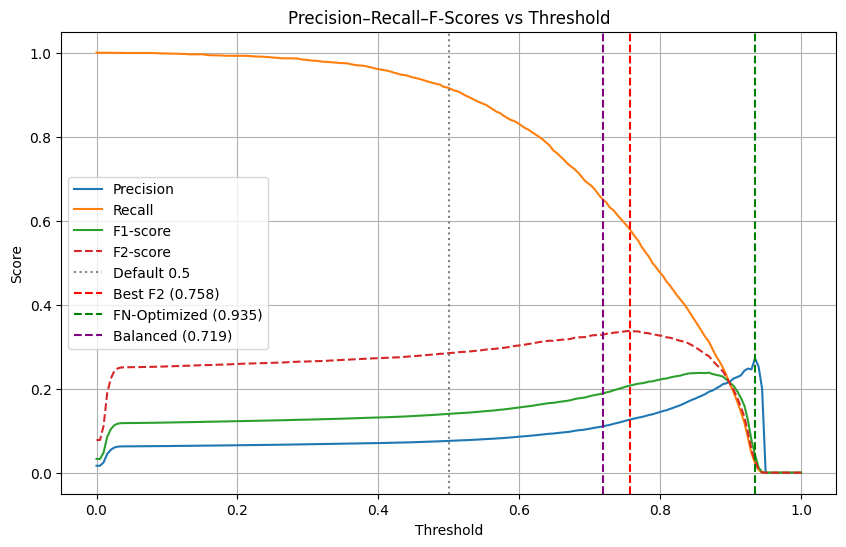

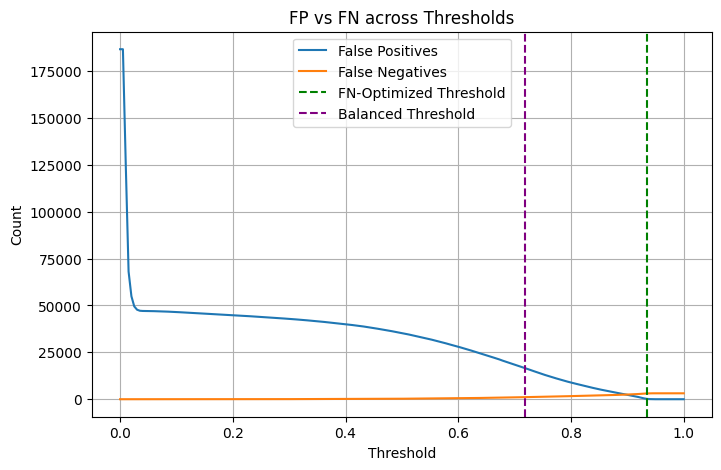

In [ ]:
# --- Plot Precision, Recall, F1 vs Threshold ---
plt.figure(figsize=(10,6))
plt.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision")
plt.plot(metrics_df["threshold"], metrics_df["recall"], label="Recall")
plt.plot(metrics_df["threshold"], metrics_df["f1"], label="F1-score")
plt.plot(metrics_df["threshold"], metrics_df["f2"], label="F2-score", linestyle="--")

# Mark thresholds
plt.axvline(0.5, color="grey", linestyle=":", label="Default 0.5")
plt.axvline(best_thresh, color="red", linestyle="--", label=f"Best F2 ({best_thresh:.3f})")
plt.axvline(best_thresh_fn, color="green", linestyle="--", label=f"FN-Optimized ({best_thresh_fn:.3f})")

plt.title("Precision–Recall–F-Scores vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
# plt.show()

plt.axvline(best_balanced_thresh, color="purple", linestyle="--", label=f"Balanced ({best_balanced_thresh:.3f})")
plt.legend()
plt.show()


# --- Optional: visualize FP vs FN trade-off ---
plt.figure(figsize=(8,5))
plt.plot(metrics_df["threshold"], metrics_df["FP"], label="False Positives")
plt.plot(metrics_df["threshold"], metrics_df["FN"], label="False Negatives")
plt.axvline(best_thresh_fn, color="green", linestyle="--", label="FN-Optimized Threshold")
plt.axvline(best_balanced_thresh, color="purple", linestyle="--", label="Balanced Threshold")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("FP vs FN across Thresholds")
plt.legend()
plt.grid(True)
plt.show()


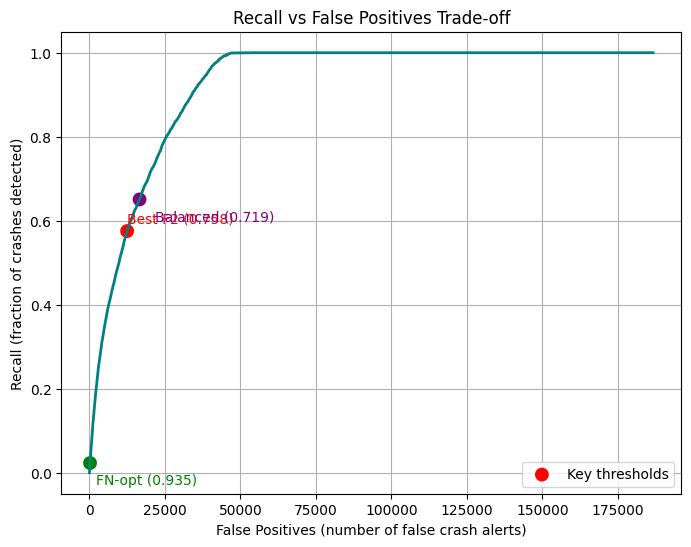

In [ ]:
# --- Plot Recall vs False Positives Trade-off ---
plt.figure(figsize=(8,6))
plt.plot(metrics_df["FP"], metrics_df["recall"], color="teal", lw=2)
plt.scatter(
    [metrics_df.loc[metrics_df["threshold"].sub(best_thresh).abs().idxmin(), "FP"],
     metrics_df.loc[metrics_df["threshold"].sub(best_thresh_fn).abs().idxmin(), "FP"],
     metrics_df.loc[metrics_df["threshold"].sub(best_balanced_thresh).abs().idxmin(), "FP"]],
    [metrics_df.loc[metrics_df["threshold"].sub(best_thresh).abs().idxmin(), "recall"],
     metrics_df.loc[metrics_df["threshold"].sub(best_thresh_fn).abs().idxmin(), "recall"],
     metrics_df.loc[metrics_df["threshold"].sub(best_balanced_thresh).abs().idxmin(), "recall"]],
    color=["red","green","purple"], s=80, label="Key thresholds"
)

# Annotate points
plt.text(metrics_df.loc[metrics_df["threshold"].sub(best_thresh).abs().idxmin(), "FP"],
         metrics_df.loc[metrics_df["threshold"].sub(best_thresh).abs().idxmin(), "recall"] + 0.02,
         f"Best F2 ({best_thresh:.3f})", color="red")

plt.text(metrics_df.loc[metrics_df["threshold"].sub(best_balanced_thresh).abs().idxmin(), "FP"] + 5000,
         metrics_df.loc[metrics_df["threshold"].sub(best_balanced_thresh).abs().idxmin(), "recall"] - 0.05,
         f"Balanced ({best_balanced_thresh:.3f})", color="purple")

plt.text(metrics_df.loc[metrics_df["threshold"].sub(best_thresh_fn).abs().idxmin(), "FP"] + 2000,
         metrics_df.loc[metrics_df["threshold"].sub(best_thresh_fn).abs().idxmin(), "recall"] - 0.05,
         f"FN-opt ({best_thresh_fn:.3f})", color="green")

plt.xlabel("False Positives (number of false crash alerts)")
plt.ylabel("Recall (fraction of crashes detected)")
plt.title("Recall vs False Positives Trade-off")
plt.grid(True)
plt.legend()
plt.show()


**Given the dataset’s strong class imbalance (only 1.6% crashes), the balanced threshold (0.719) offers the most practical compromise, maintaining about 65% crash detection with a manageable false alert rate.**

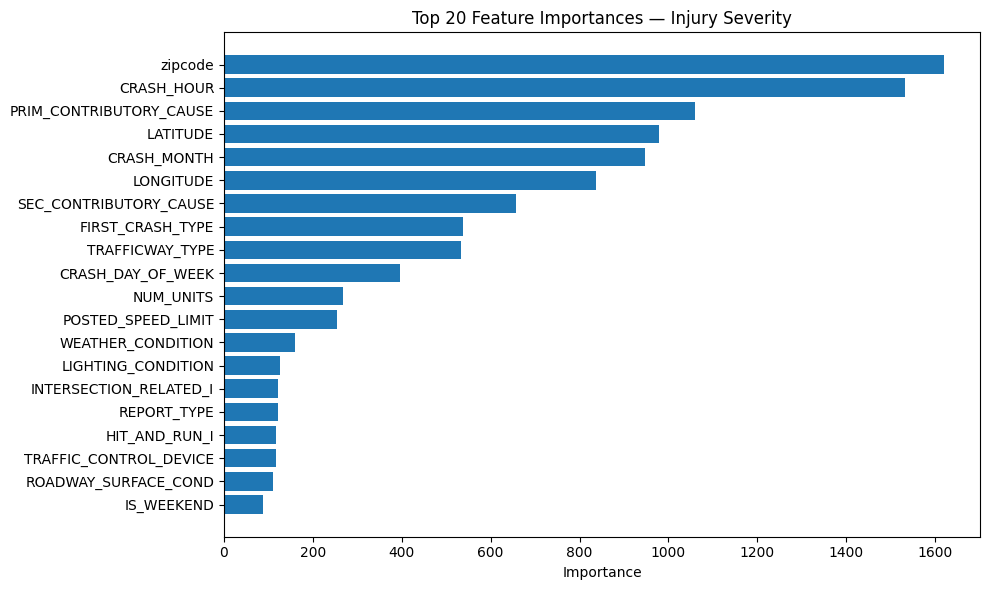

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Get feature importance values ---
importance_df = pd.DataFrame({
    'feature': lgbm.feature_name_,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

# ---Plot the top 20 important features ---
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances — Injury Severity')
plt.tight_layout()
plt.show()



In [ ]:
# --- reduced feature set without contributory causes ---
X_reduced = df_model.drop(columns=['PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE'])
y_reduced = y

# Keep categorical dtype conversions for remaining categorical columns
for col in categorical_cols_final:
    if col in X_reduced.columns:
        X_reduced[col] = X_reduced[col].astype('category')

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_reduced,
    test_size=0.2, random_state=42, stratify=y_reduced
)


lgbm_reduced = LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=127,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgbm_reduced.fit(
    X_train_r, y_train_r,
    categorical_feature=[c for c in X_reduced.columns if str(X_reduced[c].dtype) == 'category'],
    eval_set=[(X_test_r, y_test_r)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=100)]
)

# --- Evaluate ---
probs_r = lgbm_reduced.predict_proba(X_test_r)[:,1]
pred_r = (probs_r >= 0.719).astype(int)
print("\nWithout contributory causes:")
print("ROC-AUC:", roc_auc_score(y_test_r, probs_r).round(4))
print(classification_report(y_test_r, pred_r, digits=3))

# --- Confusion Matrix ---
cm_r = confusion_matrix(y_test_r, pred_r)
print("Confusion Matrix @0.719:\n", cm_r)


[LightGBM] [Info] Number of positive: 12633, number of negative: 746655
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.311420 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 783
[LightGBM] [Info] Number of data points in the train set: 759288, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.920974	valid_0's binary_logloss: 0.28097
Early stopping, best iteration is:
[61]	valid_0's auc: 0.922321	valid_0's binary_logloss: 0.309022

Without contributory causes:
ROC-AUC: 0.9223
              precision    recall  f1-score   support

           0      0.994     0.903     0.946    186664
           1      0.103     0.660     0.178      3158

    acc

The contributory-cause columns are not critical for predictive accuracy.
They provide mild contextual value but are not leakage sources — the model performs just as well without them.

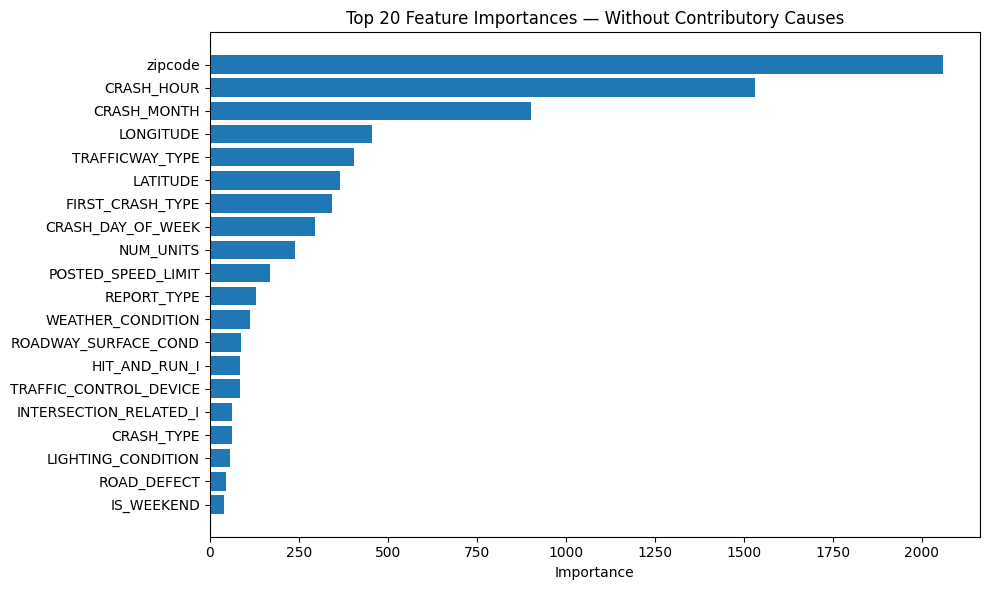

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Get new feature importances ---
importance_df_reduced = pd.DataFrame({
    'feature': lgbm_reduced.feature_name_,
    'importance': lgbm_reduced.feature_importances_
}).sort_values('importance', ascending=False)

# --- Plot the top 20 important features ---
plt.figure(figsize=(10, 6))
plt.barh(importance_df_reduced['feature'][:20][::-1], importance_df_reduced['importance'][:20][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances — Without Contributory Causes')
plt.tight_layout()
plt.show()



In [ ]:
# Make a copy to be safe
df_reg = df_crashes.copy()

# --- Composite severity score calculation ---
# Weighted sum of all injury types (based on seriousness)
df_reg["TARGET_SEVERITY_1_10"] = (
      df_reg["INJURIES_FATAL"] * 10
    + df_reg["INJURIES_INCAPACITATING"] * 8
    + df_reg["INJURIES_NON_INCAPACITATING"] * 6
    + df_reg["INJURIES_REPORTED_NOT_EVIDENT"] * 4
    + df_reg["INJURIES_NO_INDICATION"] * 1
)

# Normalize to 1–10 scale
df_reg["TARGET_SEVERITY_1_10"] = df_reg["TARGET_SEVERITY_1_10"].clip(1, 10)

print(df_reg["TARGET_SEVERITY_1_10"].describe())


count    949110.000000
mean          2.864446
std           2.265680
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: TARGET_SEVERITY_1_10, dtype: float64


In [ ]:
# Regression Model (1–10)


from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Define features and target ---
X_reg = df_model.copy()
y_reg = df_reg["TARGET_SEVERITY_1_10"]  # numeric 1–10 score you created earlier

# ---Convert categorical columns to category dtype ---
for col in categorical_cols_final:
    if col in X_reg.columns:
        X_reg[col] = X_reg[col].astype("category")

# ---Train / test split ---
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ---LightGBM Regressor ---
lgbm_reg = LGBMRegressor(
    objective="regression",
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=127,
    feature_fraction=0.7,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1
)

lgbm_reg.fit(
    X_train_r, y_train_r,
    eval_set=[(X_test_r, y_test_r)],
    eval_metric="l2"
)

# --- Evaluate ---
y_pred_r = lgbm_reg.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.326638 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 759288, number of used features: 29
[LightGBM] [W

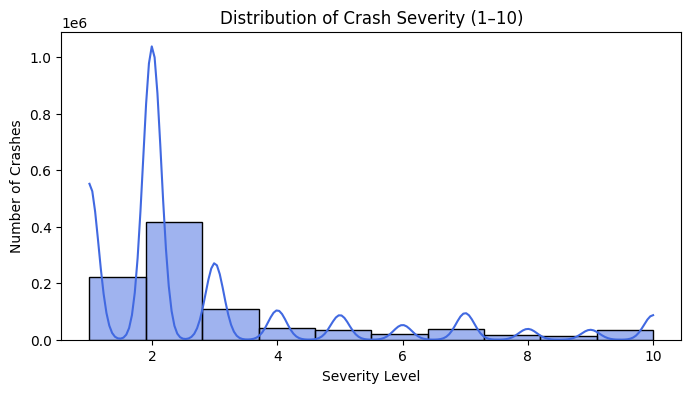

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(y_reg, bins=10, kde=True, color='royalblue')
plt.title("Distribution of Crash Severity (1–10)")
plt.xlabel("Severity Level")
plt.ylabel("Number of Crashes")
plt.show()


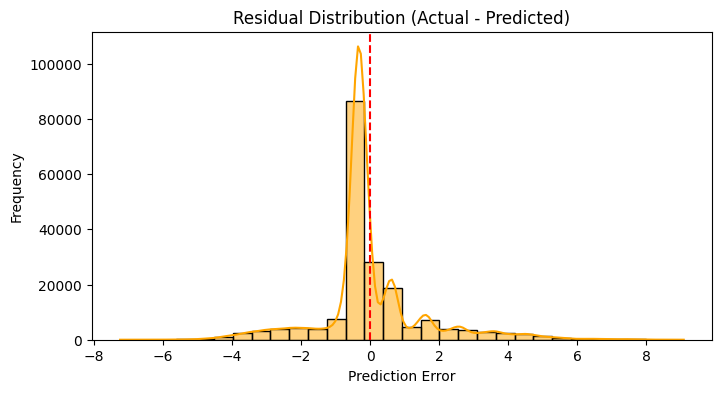

In [ ]:
residuals = y_test_r - y_pred_r
plt.figure(figsize=(8,4))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--')
plt.show()


/tmp/ipython-input-3394084220.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: mean_absolute_error(g["Actual"], g["Predicted"]))


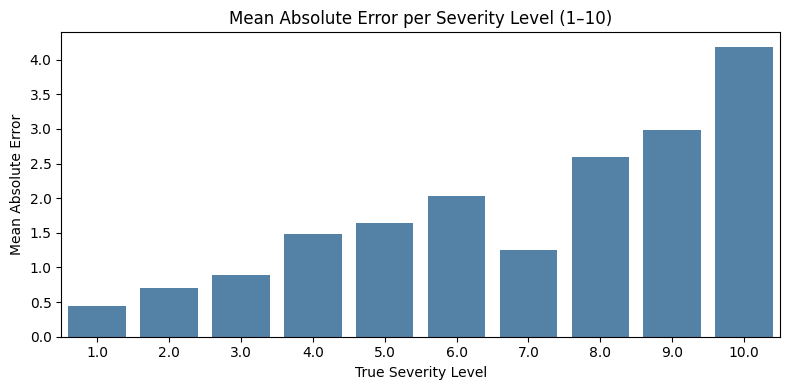

   Actual       MAE
0     1.0  0.438353
1     2.0  0.708707
2     3.0  0.897463
3     4.0  1.487275
4     5.0  1.638089
5     6.0  2.031785
6     7.0  1.253114
7     8.0  2.588722
8     9.0  2.978336
9    10.0  4.184358


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# Create DataFrame of actual vs predicted values
df_eval = pd.DataFrame({
    "Actual": y_test_r,
    "Predicted": y_pred_r
})

# Compute MAE for each actual severity level
mae_per_level = (
    df_eval.groupby("Actual")
    .apply(lambda g: mean_absolute_error(g["Actual"], g["Predicted"]))
    .reset_index(name="MAE")
)

# --- Plot ---
plt.figure(figsize=(8,4))
sns.barplot(x="Actual", y="MAE", data=mae_per_level, color="steelblue")
plt.title("Mean Absolute Error per Severity Level (1–10)")
plt.xlabel("True Severity Level")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.show()

print(mae_per_level)
